# Bangla Hallucination Detection — Starter Notebook

Predict whether a Bangla LLM response (`response_bn`) to a prompt (`prompt_bn`), optionally
grounded in a `context`, is faithful (`label = 1`) or hallucinated (`label = 0`).

Full column/format details are in `dataset_description.md`.

**Outline**
1. Load the data
2. Explore it (label balance, context coverage, text lengths)
3. Build a TF-IDF + Logistic Regression baseline
4. Evaluate it with cross-validation
5. Produce a `submission.csv`


## 1. Load the data

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
)

RANDOM_STATE = 42
DATA_PATH = "/kaggle/input/competitions/bengali-hallucination/dataset samples.json"


In [2]:
with open(DATA_PATH, encoding="utf-8") as f:
    records = json.load(f)

df = pd.DataFrame(records)
print(f"{len(df)} rows, columns: {list(df.columns)}")
df.head()


299 rows, columns: ['context', 'prompt_bn', 'response_bn', 'label']


,context,prompt_bn,response_bn,label
0,উইন্ডোজে ইউনিকোড ভিত্তিক বাংলা লেখার জন্য ২০০৩...,অভ্র কিবোর্ড কে উদ্ভাবন করেন ?,মেহদী হাসান খান,1
1,[NULL],"""ধান্ধা"" এর ভাবার্থ কী?",কোন অসৎ উদ্দেশ্য,1
2,[NULL],‘কাঁঠালপাড়া’য় জন্মগ্রহণ করেন কোন লেখক?,শরৎচন্দ্র চট্টোপাধ্যায়,0
3,তারেক মাসুদ পরিচালিত প্রথম স্বল্পদৈর্ঘ্য চলচ্চ...,তারেক মাসুদ পরিচালিত সর্বশেষ বাংলা চলচ্চিত্রটি...,রানওয়ে,0
4,[NULL],৩০ থেকে ৪০ পর্যন্ত সংখ্যা থেকে যে কোন একটিকে ই...,৬/১১,0


In [3]:
# A handful of responses are purely numeric ("-2", "3", ...) and load from JSON as
# ints rather than strings, which breaks any text vectorizer downstream. Coerce both
# text fields to str so every row is treated as text.
for col in ["prompt_bn", "response_bn"]:
    df[col] = df[col].astype(str)

# The context column uses several stand-ins for "no context" (missing value, empty
# string, the literal string "[NULL]"). Normalize all of them to "" and derive a flag.
NO_CONTEXT_VALUES = {"", "nan", "NaN", "[NULL]", None}

def clean_context(value):
    if pd.isna(value) or str(value).strip() in NO_CONTEXT_VALUES:
        return ""
    return str(value).strip()

df["context"] = df["context"].apply(clean_context)
df["has_context"] = df["context"].str.len() > 0


## 2. Explore the data

In [4]:
print("Label balance (1 = faithful, 0 = hallucinated):")
print(df["label"].value_counts(normalize=True).rename("share").to_frame())

print("\nContext coverage (rows with vs. without a supporting passage):")
print(df["has_context"].value_counts())

print("\nLabel balance split by whether context is present:")
print(df.groupby("has_context")["label"].value_counts(normalize=True).unstack().round(3))


Label balance (1 = faithful, 0 = hallucinated):
          share
label          
1      0.545151
0      0.454849

Context coverage (rows with vs. without a supporting passage):
has_context
False    169
True     130
Name: count, dtype: int64

Label balance split by whether context is present:
label            0      1
has_context              
False        0.527  0.473
True         0.362  0.638


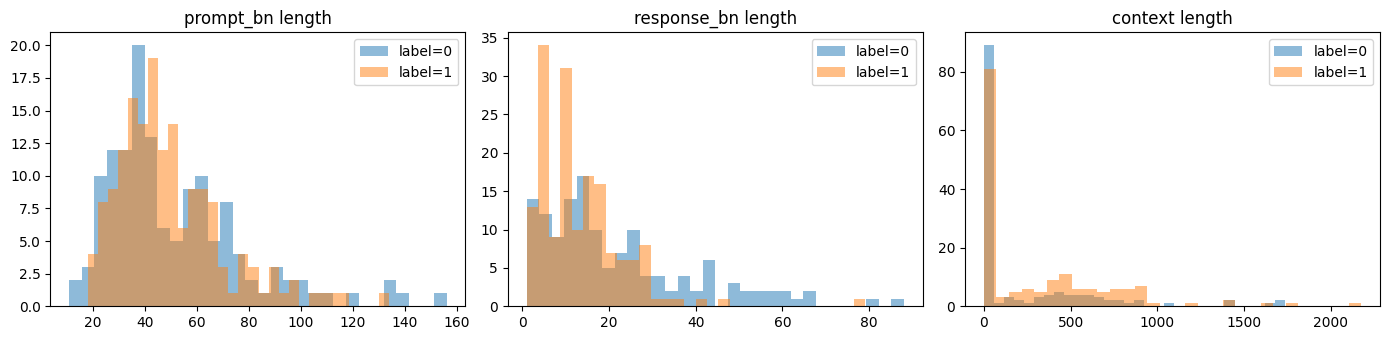

In [5]:
text_cols = ["prompt_bn", "response_bn", "context"]
for col in text_cols:
    df[f"{col}_len"] = df[col].str.len()

fig, axes = plt.subplots(1, len(text_cols), figsize=(14, 3.5))
for ax, col in zip(axes, text_cols):
    for label, subset in df.groupby("label"):
        ax.hist(subset[f"{col}_len"], bins=30, alpha=0.5, label=f"label={label}")
    ax.set_title(f"{col} length")
    ax.legend()
plt.tight_layout()
plt.show()


## 3. Baseline model

A text-classification baseline: character n-gram TF-IDF on `prompt_bn` and `response_bn`
separately (character n-grams tend to work better than word n-grams for Bangla, since word
tokenization is less reliable), concatenated and fed into a Logistic Regression.

This ignores `context` entirely — see the ideas at the bottom of this notebook for how to
bring it in.


In [6]:
def select_column(name):
    # .to_numpy() (rather than returning the raw Series) sidesteps a pandas-output
    # auto-wrapping quirk in recent scikit-learn versions that otherwise corrupts the text.
    return FunctionTransformer(lambda frame: frame[name].to_numpy(), validate=False)

def tfidf_branch(name):
    return Pipeline([
        ("select", select_column(name)),
        ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), max_features=20_000)),
    ])

baseline = Pipeline([
    ("features", FeatureUnion([
        ("prompt", tfidf_branch("prompt_bn")),
        ("response", tfidf_branch("response_bn")),
    ])),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])


## 4. Cross-validated evaluation

In [7]:
def report(y_true, y_pred, y_score=None, name="model"):
    print(f"{'=' * 45}\n  {name}\n{'=' * 45}")
    print(f"  Accuracy   : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Macro-F1   : {f1_score(y_true, y_pred, average='macro'):.4f}  <- primary metric")
    print(f"  F1 (label=1): {f1_score(y_true, y_pred, pos_label=1):.4f}")
    print(f"  F1 (label=0): {f1_score(y_true, y_pred, pos_label=0):.4f}")
    if y_score is not None:
        print(f"  AUC-ROC    : {roc_auc_score(y_true, y_score):.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=["hallucinated (0)", "faithful (1)"]))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
y = df["label"].values

cv_pred = cross_val_predict(baseline, df, y, cv=cv, method="predict")
cv_proba = cross_val_predict(baseline, df, y, cv=cv, method="predict_proba")[:, 1]

report(y, cv_pred, cv_proba, name="TF-IDF + Logistic Regression (5-fold CV)")


  TF-IDF + Logistic Regression (5-fold CV)
  Accuracy   : 0.5518
  Macro-F1   : 0.5456  <- primary metric
  F1 (label=1): 0.5988
  F1 (label=0): 0.4924
  AUC-ROC    : 0.5792

                  precision    recall  f1-score   support

hallucinated (0)       0.51      0.48      0.49       136
    faithful (1)       0.58      0.61      0.60       163

        accuracy                           0.55       299
       macro avg       0.55      0.55      0.55       299
    weighted avg       0.55      0.55      0.55       299



In [8]:
print("Confusion matrix (rows = true, cols = predicted), order = [0, 1]:")
print(confusion_matrix(y, cv_pred))


Confusion matrix (rows = true, cols = predicted), order = [0, 1]:
[[ 65  71]
 [ 63 100]]


## 5. Fit on all data and generate a submission

Once a real `test.csv` is available (same columns, minus `label`), point `TEST_PATH` at it
and run this cell to produce `submission.csv` in the format described in
`dataset_description.md` (`id`, `label`).


In [9]:
baseline.fit(df, y)

TEST_PATH = "/kaggle/input/competitions/bengali-hallucination/test set.csv"  # update once the real test file is available

try:
    test_df = pd.read_csv(TEST_PATH)
    for col in ["prompt_bn", "response_bn"]:
        test_df[col] = test_df[col].astype(str)
    test_df["context"] = test_df["context"].apply(clean_context)
    test_pred = baseline.predict(test_df)

    submission = pd.DataFrame({
        "id": test_df["id"] if "id" in test_df.columns else range(len(test_df)),
        "label": test_pred,
    })
    submission.to_csv("submission.csv", index=False)
    print(f"Wrote submission.csv with {len(submission)} rows.")
    submission.head()
except FileNotFoundError:
    print(f'No test file found at "{TEST_PATH}" yet — this cell will work once one is added.')


Wrote submission.csv with 2516 rows.


## Ideas to improve on this baseline

- **Bring in `context`**: add features such as token/n-gram overlap, or the NLI entailment
  score from section 6, between `context` and `response_bn` — a faithful answer should be
  grounded in the context when one is given, and closed-book rows (`has_context == False`)
  likely need a different strategy (fact-checking rather than grounding).
- **Stack the NLI score into the baseline**: append `nli_entailment` as an extra feature
  column (with e.g. `0.5` or the has_context mean as a fill value for closed-book rows)
  before the `LogisticRegression` step, rather than only evaluating it standalone.
- **Try multilingual embeddings**: a sentence-transformer that supports Bangla, feeding a
  shallow classifier, in place of char-TF-IDF.
- **Error-analyze by subset**: this dataset mixes closed-book trivia, open-book QA, and
  proverb interpretation — check that macro-F1 holds up across all of them, not just in
  aggregate.


In [10]:
import torch
from transformers import pipeline

NLI_MODEL = "MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7"
device = "cuda" if torch.cuda.is_available() else "cpu"


In [11]:
print(f'Loading NLI model: {NLI_MODEL}')
nli_pipe = pipeline(
    'zero-shot-classification',
    model=NLI_MODEL,
    device=0 if device == 'cuda' else -1,
    torch_dtype=torch.float16 if device == 'cuda' else torch.float32,
)
print('NLI model ready.')


Loading NLI model: MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

...

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

NLI model ready.


In [12]:
from tqdm.auto import tqdm

def nli_entailment_score(context, response):
    result = nli_pipe(
        context,
        candidate_labels=[response],
        hypothesis_template="{}",
        multi_label=True,
    )
    return result["scores"][0]

context_rows = df[df["has_context"]]
scores = [
    nli_entailment_score(row.context, row.response_bn)
    for row in tqdm(context_rows.itertuples(), total=len(context_rows))
]

df["nli_entailment"] = np.nan
df.loc[context_rows.index, "nli_entailment"] = scores


  0%|          | 0/130 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [13]:
# Sanity-check the signal on its own: threshold it at 0.5 and score against the true
# labels, restricted to the context rows it actually applies to.
context_eval = df.loc[df["has_context"]].dropna(subset=["nli_entailment"])
nli_pred = (context_eval["nli_entailment"] > 0.5).astype(int)

report(
    context_eval["label"], nli_pred, context_eval["nli_entailment"],
    name="NLI entailment @ 0.5 threshold (context rows only)",
)


  NLI entailment @ 0.5 threshold (context rows only)
  Accuracy   : 0.7308
  Macro-F1   : 0.6941  <- primary metric
  F1 (label=1): 0.8000
  F1 (label=0): 0.5882
  AUC-ROC    : 0.7660

                  precision    recall  f1-score   support

hallucinated (0)       0.66      0.53      0.59        47
    faithful (1)       0.76      0.84      0.80        83

        accuracy                           0.73       130
       macro avg       0.71      0.69      0.69       130
    weighted avg       0.72      0.73      0.72       130



## Ideas to improve on this baseline

- **Bring in `context`**: add features such as token/n-gram overlap between `context` and
  `response_bn` — a faithful answer should be grounded in the context when one is given, and
  closed-book rows (`has_context == False`) likely need a different strategy (fact-checking
  rather than grounding).
- **Try multilingual embeddings**: a sentence-transformer that supports Bangla, feeding a
  shallow classifier, in place of char-TF-IDF.
- **Error-analyze by subset**: this dataset mixes closed-book trivia, open-book QA, and
  proverb interpretation — check that macro-F1 holds up across all of them, not just in
  aggregate.
